In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import mlflow
import shap

from src import feature_engineering as fe
from src import interpretation as interpret

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")

RANDOM_STATE = 42
N_SPLITS = 5
EXPERIMENT_NAME = "customer-churn-optuna"

from pathlib import Path

def _find_project_root():
    """Find the project root by looking for pyproject.toml."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (pyproject.toml)")

ROOT_DIR = str(_find_project_root())
DB_PATH = os.path.join(ROOT_DIR, "mlflow.db")
ARTIFACTS_DIR = os.path.join(ROOT_DIR, "mlartifacts")

# Set the tracking URI immediately to lock it to SQLite
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")

In [3]:
selected_features = [
    # Binary
    "is_silver",
    "is_germany",
    "is_spain",
    "Num_Of_Products_1",
    "Num_Of_Products_2",
    "Num_Of_Products_3",
    "Num_Of_Products_4",

    # Continuous
    "Age_x_IsActive",
    "Balance_per_Product",
    "CreditScore_per_Age",
    "Inactive_x_Balance",
    "CreditScore_x_Age",
    "Products_per_Tenure",
]
# Schema Baseline Columns Definitions
nomod_columns = []
dummyfy_columns = ['Gender']
norm_std_columns = ['Point Earned', 'Satisfaction Score', 'EstimatedSalary']

# Initialize the Feature Engineer class with the desired subset strings
feature_engineer_object = fe.DynamicFeatureEngineer(selected_features=selected_features)
binary_features = feature_engineer_object._get_all_binary_features()
continuous_features = feature_engineer_object._get_all_continuous_features()

current_layout = {
    "passthrough": nomod_columns + binary_features,
    "standard_scale": norm_std_columns + continuous_features,
    "one_hot_encode": dummyfy_columns
}

EXPERIMENT_REGISTRY = {
    "experiment_1": current_layout
}

In [38]:
# Active the experiment scope
mlflow.set_experiment(EXPERIMENT_NAME)
experiment_id = "1"  # Your experiment ID

# 2. Programmatically query your tracking history to isolate the parent run
runs_df = mlflow.search_runs(experiment_ids=[experiment_id])

# Filter out the children; find the most recent successful parent run
parent_runs = runs_df[runs_df["tags.mlflow.parentRunId"].isna() & (runs_df["status"] == "FINISHED")]
best_parent_run = parent_runs.sort_values(by="metrics.test_pr_auc", ascending=False).iloc[0]

best_run_id = best_parent_run["run_id"]
best_pr_auc = best_parent_run["metrics.test_pr_auc"]

print(f"Fetching Champion Model from Parent Run ID: {best_run_id}")
print(f"Validated Validation PR-AUC: {best_pr_auc:.4f}")

# 3. Load the model artifact directly back into your environment
model_uri = f"runs:/{best_run_id}/best_model"
loaded_pipeline = mlflow.sklearn.load_model(model_uri)

print("\nPipeline successfully loaded! Type:", type(loaded_pipeline))

Fetching Champion Model from Parent Run ID: 3baa83fba10949f99b4d570322b85014
Validated Validation PR-AUC: 0.7341



Pipeline successfully loaded! Type: <class 'sklearn.pipeline.Pipeline'>


In [22]:
# Create a dummy DataFrame representing new raw production client data
new_customers = pd.DataFrame([{
    "Card Type": "SILVER",
    "Geography": "Germany",
    "Gender": "Female",
    "Balance": 52000.0,
    "Point Earned": 450,
    "CreditScore": 680,
    "Age": 38,
    "Tenure": 4,
    "Satisfaction Score": 4,
    "EstimatedSalary": 85000.0,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1
}])

# Generate classifications (0 = Retained, 1 = Churn)
predictions = loaded_pipeline.predict(new_customers)

# Generate raw prediction probability score arrays
probabilities = loaded_pipeline.predict_proba(new_customers)[:, 1]

print(f"Prediction Target Assignment: {predictions[0]}")
print(f"Calculated Churn Probability: {probabilities[0]:.2%}")

Prediction Target Assignment: 0
Calculated Churn Probability: 6.68%


In [23]:
# Extract Isolated Pipeline Steps
preprocessor = loaded_pipeline.named_steps['preprocessing']
model = loaded_pipeline.named_steps['model']

In [24]:
X_train.loc[0]

RowNumber                  4979
CustomerId             15758939
Surname                    Bray
CreditScore                 540
Geography               Germany
Gender                     Male
Age                          35
Tenure                        7
Balance               127801.88
NumOfProducts                 1
HasCrCard                     0
IsActiveMember                1
EstimatedSalary        84239.46
Complain                      0
Satisfaction Score            5
Card Type                  GOLD
Point Earned                830
Name: 0, dtype: object

In [25]:
fe = loaded_pipeline.named_steps["feature_engineering"]

X_fe = fe.transform(X_train)

X_prepared = preprocessor.transform(X_fe)

In [26]:
preprocessor = loaded_pipeline.named_steps["preprocessing"]

X_prepared = preprocessor.transform(X_fe)

print("Model input shape:", X_prepared.shape)

Model input shape: (6400, 18)


In [27]:
fe = loaded_pipeline.named_steps["feature_engineering"]

print("Selected engineered features:")
print(len(fe.selected_features))
print(fe.selected_features)

X_fe = fe.transform(X_train)

print("\nColumns after Feature Engineering:")
print(len(X_fe.columns))
print(X_fe.columns.tolist())

Selected engineered features:
13
['Age_x_IsActive', 'Balance_per_Product', 'CreditScore_per_Age', 'Inactive_x_Balance', 'CreditScore_x_Age', 'Products_per_Tenure', 'is_silver', 'is_germany', 'is_spain', 'Num_Of_Products_1', 'Num_Of_Products_2', 'Num_Of_Products_3', 'Num_Of_Products_4']

Columns after Feature Engineering:
30
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'Age_x_IsActive', 'Balance_per_Product', 'CreditScore_per_Age', 'Inactive_x_Balance', 'CreditScore_x_Age', 'Products_per_Tenure', 'is_silver', 'is_germany', 'is_spain', 'Num_Of_Products_1', 'Num_Of_Products_2', 'Num_Of_Products_3', 'Num_Of_Products_4']


In [28]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_prepared, columns=feature_names)

In [29]:
importance_df = interpret.calculate_global_importance(model, feature_names)
importance_df.head(20)

,feature,importance,cumulative_importance
0,pass__Num_Of_Products_2,0.265845,0.265845
1,pass__Num_Of_Products_1,0.107044,0.372889
2,pass__Num_Of_Products_3,0.096855,0.469744
3,pass__is_germany,0.080279,0.550023
4,num__CreditScore_per_Age,0.068842,0.618864
5,num__CreditScore_x_Age,0.052572,0.671436
6,num__Age_x_IsActive,0.043654,0.715090
7,num__Inactive_x_Balance,0.040855,0.755945
8,num__Balance_per_Product,0.038694,0.794639
9,pass__Num_Of_Products_4,0.037723,0.832363


In [30]:
# Calculate game-theoretic contribution metrics
shap_values = interpret.compute_shap_values(model, X_train_df)

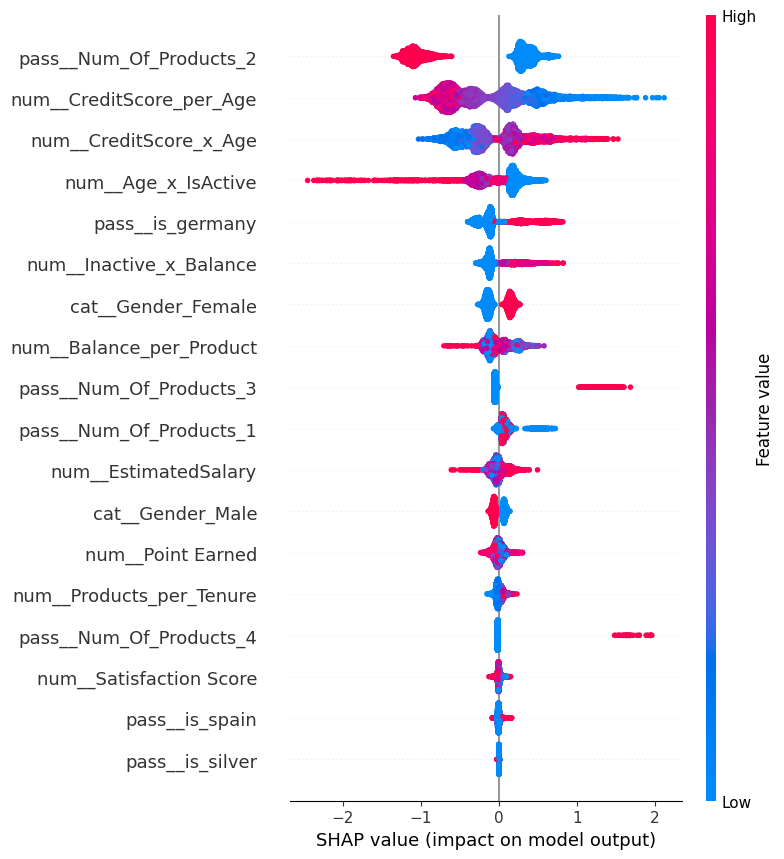

In [31]:
# Dot Distribution Plot
interpret.plot_shap_summary(shap_values, X_train_df, plot_type=None)

In [32]:
X_train_df.columns

Index(['cat__Gender_Female', 'cat__Gender_Male', 'num__Point Earned',
       'num__Satisfaction Score', 'num__EstimatedSalary',
       'num__Age_x_IsActive', 'num__Balance_per_Product',
       'num__CreditScore_per_Age', 'num__Inactive_x_Balance',
       'num__CreditScore_x_Age', 'num__Products_per_Tenure', 'pass__is_silver',
       'pass__is_germany', 'pass__is_spain', 'pass__Num_Of_Products_1',
       'pass__Num_Of_Products_2', 'pass__Num_Of_Products_3',
       'pass__Num_Of_Products_4'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

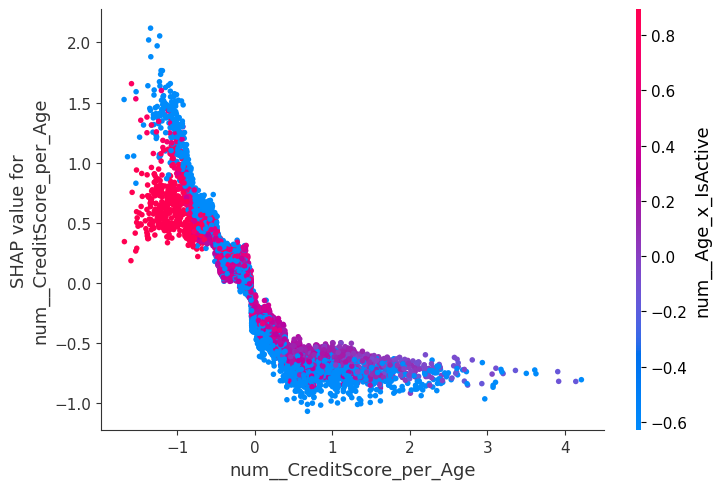

In [33]:
interpret.plot_shap_dependence("num__CreditScore_per_Age", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

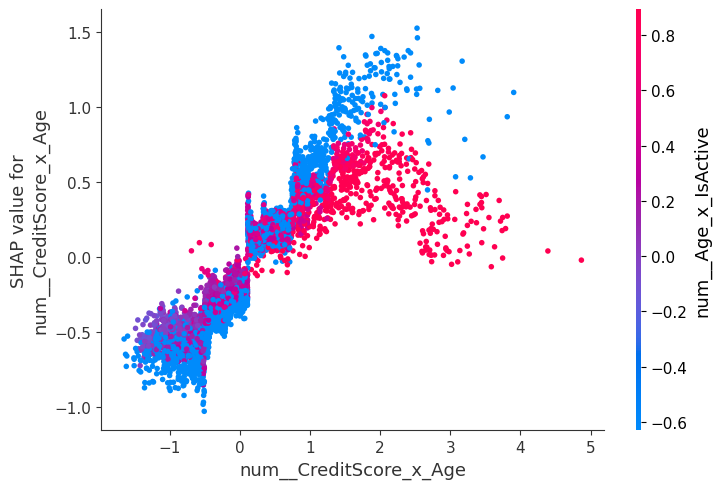

In [34]:
interpret.plot_shap_dependence("num__CreditScore_x_Age", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

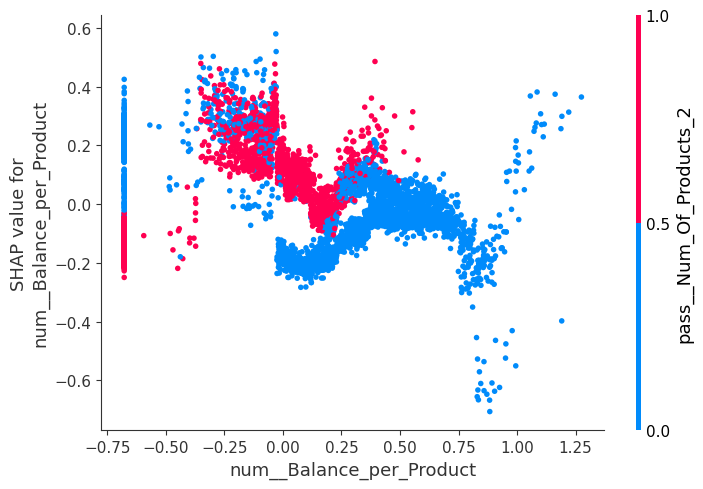

In [35]:
interpret.plot_shap_dependence("num__Balance_per_Product", shap_values, X_train_df)

In [18]:
def extract_pipeline_components(pipeline):
    """
    Extracts the main components from a fitted sklearn pipeline.

    Args:
        pipeline: Fitted sklearn Pipeline containing feature engineering,
            preprocessing, and model steps.

    Returns:
        tuple:
            Feature engineering step, preprocessing step, and trained model.
    """

    print("\n========================")
    print("EXTRACT PIPELINE COMPONENTS")
    print("========================")

    fe_step = pipeline.named_steps["feature_engineering"]
    preprocessor = pipeline.named_steps["preprocessing"]
    model = pipeline.named_steps["model"]

    return fe_step, preprocessor, model


def print_model_details(best_run, pipeline):
    """
    Prints MLflow metadata and trained model hyperparameters.

    Args:
        best_run: MLflow run object containing experiment information.
        pipeline: Fitted sklearn Pipeline.

    Returns:
        None
    """

    print("\n========================")
    print("BEST RUN")
    print("========================")

    print(f"Run ID: {best_run.run_id}")

    if "metrics.average_precision" in best_run:
        print(
            f"Average Precision: "
            f"{best_run['metrics.average_precision']:.5f}"
        )

    model = pipeline.named_steps["model"]

    print("\n========================")
    print("MODEL PARAMETERS")
    print("========================")

    for param_name, param_value in model.get_params().items():
        print(f"{param_name}: {param_value}")


def transform_raw_data(
    pipeline,
    X_raw: pd.DataFrame,
):
    """
    Applies feature engineering and preprocessing transformations.

    Args:
        pipeline: Fitted sklearn Pipeline.
        X_raw: Raw customer dataframe.

    Returns:
        pd.DataFrame:
            Transformed dataframe ready for model input.
    """

    print("\n========================")
    print("TRANSFORM RAW DATA")
    print("========================")

    fe_step = pipeline.named_steps["feature_engineering"]
    preprocessor = pipeline.named_steps["preprocessing"]

    print("\nApplying feature engineering...")

    X_engineered = fe_step.transform(X_raw)

    print("Applying preprocessing...")

    X_transformed = preprocessor.transform(X_engineered)

    feature_names = preprocessor.get_feature_names_out()

    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X_raw.index,
    )

    print(
        f"Generated {X_transformed_df.shape[1]} transformed features."
    )

    return X_transformed_df


def predict_customer_churn(
    pipeline,
    X_raw: pd.DataFrame,
    threshold: float = 0.5,
):
    """
    Predicts churn probability and classification labels.

    Args:
        pipeline: Fitted sklearn Pipeline.
        X_raw: Raw customer dataframe.
        threshold: Probability threshold for churn classification.

    Returns:
        pd.DataFrame:
            Churn probabilities and predictions.
    """

    print("\n========================")
    print("CUSTOMER CHURN PREDICTION")
    print("========================")

    print("Generating churn probabilities...")

    probabilities = pipeline.predict_proba(X_raw)[:, 1]

    print(
        f"Applying classification threshold: {threshold}"
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    results = pd.DataFrame(
        {
            "churn_probability": probabilities,
            "prediction": predictions,
        },
        index=X_raw.index,
    )

    print(
        f"Generated predictions for {len(results)} customers."
    )

    return results


def generate_shap_explanations(
    pipeline,
    X_raw: pd.DataFrame,
):
    """
    Generates SHAP explanations for model predictions.

    Args:
        pipeline: Fitted sklearn Pipeline containing preprocessing
            and trained model.
        X_raw: Raw customer dataframe.

    Returns:
        tuple:
            SHAP explainer, SHAP values, transformed dataframe.
    """

    print("\n========================")
    print("GENERATE SHAP EXPLANATIONS")
    print("========================")

    model = pipeline.named_steps["model"]

    print("Transforming input data...")

    X_transformed_df = transform_raw_data(
        pipeline,
        X_raw,
    )

    print("Creating SHAP explainer...")

    explainer = shap.TreeExplainer(model)

    print("Calculating SHAP values...")

    shap_values = explainer(
        X_transformed_df
    )

    print("SHAP explanation completed.")

    return (
        explainer,
        shap_values,
        X_transformed_df,
    )


def plot_global_shap(
    shap_values,
):
    """
    Creates a global SHAP beeswarm plot.

    Args:
        shap_values: SHAP explanation object.

    Returns:
        None
    """

    print("\n========================")
    print("GLOBAL SHAP FEATURE IMPACT")
    print("========================")

    shap.plots.beeswarm(
        shap_values,
        max_display=20,
    )


def plot_shap_importance(
    shap_values,
):
    """
    Creates a SHAP feature importance bar chart.

    Args:
        shap_values: SHAP explanation object.

    Returns:
        None
    """

    print("\n========================")
    print("SHAP FEATURE IMPORTANCE")
    print("========================")

    shap.plots.bar(
        shap_values,
        max_display=20,
    )


def explain_customer(
    shap_values,
    row_idx: int = 0,
):
    """
    Generates a local SHAP explanation for one customer.

    Args:
        shap_values: SHAP explanation object.
        row_idx: Customer row index to explain.

    Returns:
        None
    """

    print("\n========================")
    print("SINGLE CUSTOMER EXPLANATION")
    print("========================")

    print(
        f"Explaining customer index: {row_idx}"
    )

    shap.plots.waterfall(
        shap_values[row_idx],
        max_display=15,
    )


BEST RUN
Run ID: 3baa83fba10949f99b4d570322b85014

MODEL PARAMETERS
objective: binary:logistic
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: 0.5163311685111722
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: aucpr
feature_types: None
feature_weights: None
gamma: 3.2099584250585966
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: 0.028208365131823353
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: 5
max_leaves: None
min_child_weight: 2
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: 1403
n_jobs: -1
num_parallel_tree: None
random_state: 42
reg_alpha: 2.7442001852027416e-07
reg_lambda: 3.527615965634737e-07
sampling_method: None
scale_pos_weight: 1.189474235403715
subsample: 0.9741488207907273
tree_method: None
validate_parameters: None
verbosity: None

CUSTOMER CHURN PREDICTION
Gener

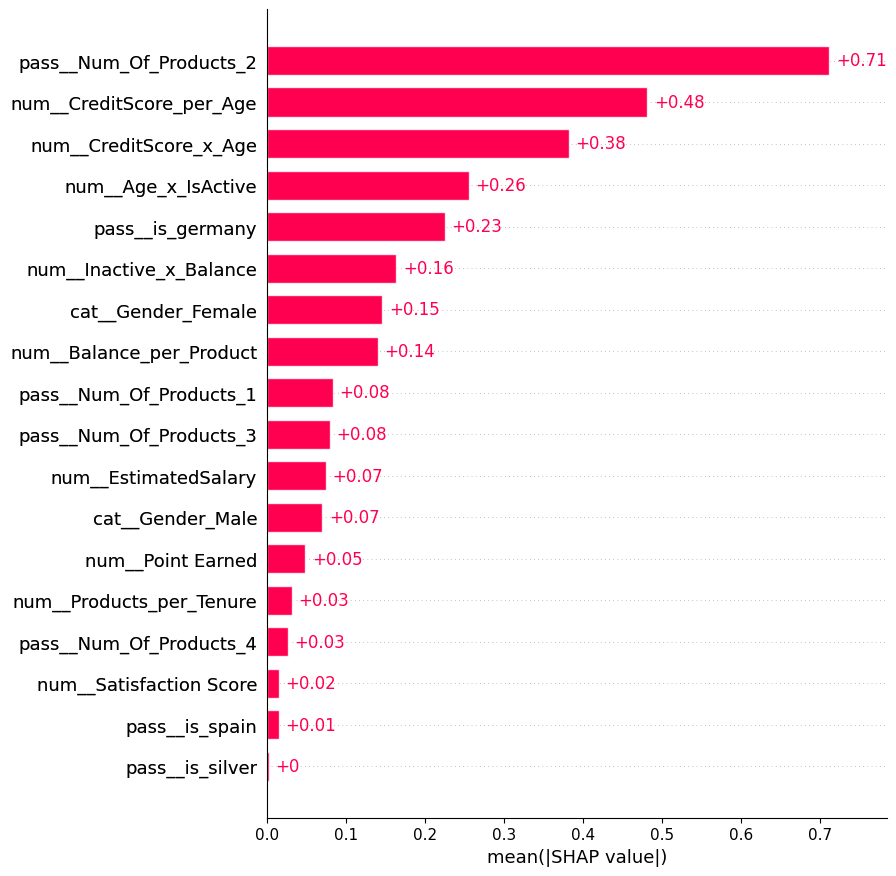


GLOBAL SHAP FEATURE IMPACT


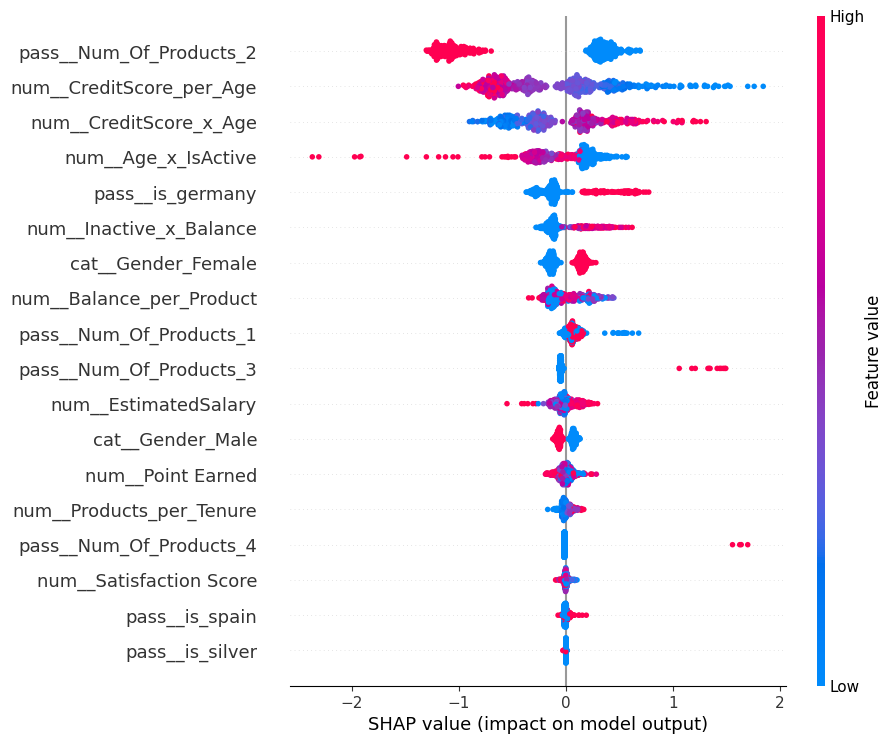


SINGLE CUSTOMER EXPLANATION
Explaining customer index: 0


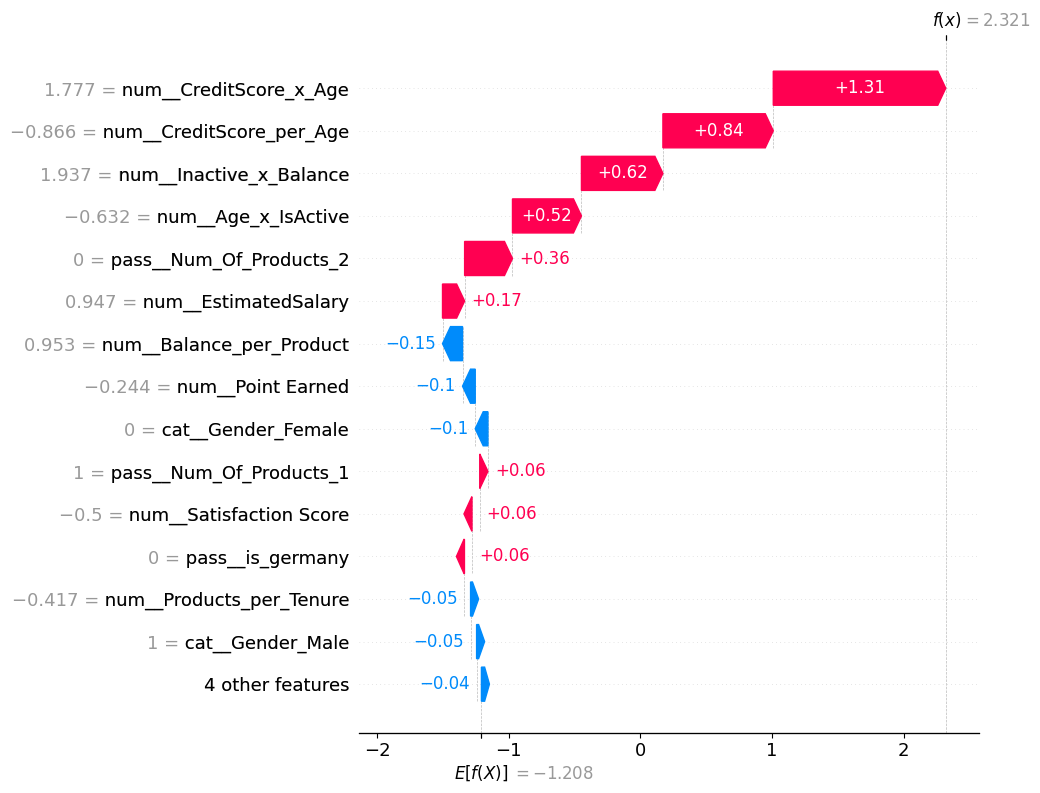

In [19]:
pipeline = loaded_pipeline
best_run = best_parent_run

print_model_details(
    best_run,
    pipeline,
)

predictions = predict_customer_churn(
    pipeline,
    X_test.head(10),
)

print(predictions)

(
    explainer,
    shap_values,
    X_transformed_df,
) = generate_shap_explanations(
    pipeline,
    X_test.sample(
        500,
        random_state=42,
    ),
)

plot_shap_importance(
    shap_values
)

plot_global_shap(
    shap_values
)

explain_customer(
    shap_values,
    row_idx=0,
)

In [36]:
X_test.iloc[0]

RowNumber                 9328
CustomerId            15624715
Surname                     Ma
CreditScore                593
Geography                Spain
Gender                  Female
Age                         40
Tenure                       2
Balance                    0.0
NumOfProducts                1
HasCrCard                    1
IsActiveMember               1
EstimatedSalary        5194.95
Complain                     0
Satisfaction Score           2
Card Type               SILVER
Point Earned               678
Name: 0, dtype: object

In [37]:
shap_values[0]

array([-0.08566647, -0.03495538,  0.27343735, -0.05377036, -0.07523111,
       -0.3335637 ,  0.0877518 ,  0.18323548, -0.16846704, -0.52004206,
       -0.03734924, -0.00296396,  0.59310985,  0.00086254,  0.08049019,
        0.3769074 , -0.05373523, -0.01274699], dtype=float32)